In [1]:
#STEP 1- IMPORTING LIBRARIES
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pickle
import random

In [2]:
#STEP 2- LOAD DATASET
fake_path = "News _dataset/Fake.csv"
true_path = "News _dataset/True.csv"

fake_df = pd.read_csv(fake_path)
true_df = pd.read_csv(true_path)

In [3]:
#STEP 3-ADD LABELS
fake_df['label'] = 0  # Fake news
true_df['label'] = 1  # True news

In [4]:
#STEP 4-COMBINE AND SHUFFLE
data = pd.concat([fake_df, true_df], ignore_index=True)
data = data.sample(frac=1, random_state=42)  # Shuffle data

In [5]:
#STEP 5-INSPECT TEXT COLUMN
print(data.columns)
text_col = 'text'  # Replace 'text' with your actual text column name
print(data[text_col].head())

Index(['title', 'text', 'subject', 'date', 'label'], dtype='object')
22216    21st Century Wire says Ben Stein, reputable pr...
27917    WASHINGTON (Reuters) - U.S. President Donald T...
25007    (Reuters) - Puerto Rico Governor Ricardo Rosse...
1377     On Monday, Donald Trump once again embarrassed...
32476    GLASGOW, Scotland (Reuters) - Most U.S. presid...
Name: text, dtype: object


In [6]:
#STEP 6- PREPARE FEATURES AND LABELS
X = data[text_col].values
y = data['label'].values

In [7]:
#STEP 7-TRAIN-TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [8]:
#STEP 8-TF-IDF VECTORIZER
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2),
    stop_words='english'
)

X_train_vec = tfidf.fit_transform(X_train)
X_test_vec = tfidf.transform(X_test)

print("TF-IDF vectorization completed!")

TF-IDF vectorization completed!


In [9]:
#STEP 9-TRAIN RANDOM FOREST
rf_model = RandomForestClassifier(
    n_estimators=200,      # Number of trees
    random_state=42,
    n_jobs=-1               # Use all cores for faster training
)

rf_model.fit(X_train_vec, y_train)
print("Random Forest training completed!")
rf_model.fit

Random Forest training completed!


<bound method BaseForest.fit of RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42)>

In [10]:
#STEP 10-EVALUATE RANDOM FOREST
y_pred = rf_model.predict(X_test_vec)

accuracy = accuracy_score(y_test, y_pred)
print(f"Random Forest Test Accuracy: {accuracy*100:.2f}%\n")

print("Classification Report:")
print(classification_report(y_test, y_pred))

Random Forest Test Accuracy: 99.82%

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4696
           1       1.00      1.00      1.00      4284

    accuracy                           1.00      8980
   macro avg       1.00      1.00      1.00      8980
weighted avg       1.00      1.00      1.00      8980



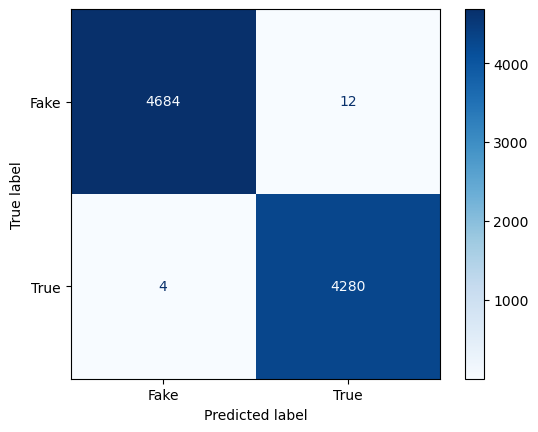

In [11]:
#STEP 11-CONFUSION MATRIX
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Fake", "True"])
disp.plot(cmap='Blues')

In [12]:
#STEP 12- RANDOM FOREST TEST PREDICTIONS
# Randomly select 5 samples from test set
indices = random.sample(range(X_test.shape[0]), 5)
sample_texts = X_test[indices]
sample_labels = y_test[indices]

sample_vec = tfidf.transform(sample_texts)
sample_preds = rf_model.predict(sample_vec)
sample_probs = rf_model.predict_proba(sample_vec)

for i, text in enumerate(sample_texts):
    actual_label = "True" if sample_labels[i] == 1 else "Fake"
    predicted_label = "True" if sample_preds[i] == 1 else "Fake"
    confidence = sample_probs[i][sample_preds[i]] * 100
    print(f"News: {text}")
    print(f"Actual Label: {actual_label}")
    print(f"Predicted Label: {predicted_label} (Confidence: {confidence:.2f}%)")
    print("-"*80)

News: WASHINGTON (Reuters) - There is disagreement within President-elect Donald Trump’s camp about the structure of the top U.S. intelligence agency when he takes office and it is unclear whether his national security adviser will prevail in advocating a reorganization, sources familiar with the matter said on Thursday. At issue is the Office of the Director of National Intelligence (ODNI), which Congress created after the Sept. 11 attacks to better coordinate the efforts of U.S. intelligence agencies to protect the United States. Trump security adviser Michael Flynn, who as head of the Pentagon’s Defense Intelligence Agency under President Barack Obama sometimes clashed with other intelligence agencies, favors restructuring and paring back the ODNI, the sources said. But one source close to the Trump transition cautioned that the outcome is not certain. “There is a general consensus that the ODNI is too big and grown too fast. Some around him (Trump) believe this, but whether they pl

In [13]:
#STEP 13-USER SPECIFIC PREDICTIONS
user_articles = [
    "New AI system predicts diseases early",
    "Celebrity found to be living on the moon!"
]

user_vec = tfidf.transform(user_articles)
user_preds = rf_model.predict(user_vec)
user_probs = rf_model.predict_proba(user_vec)

for i, article in enumerate(user_articles):
    predicted_label = "True" if user_preds[i] == 1 else "Fake"
    confidence = user_probs[i][user_preds[i]] * 100
    print(f"News: {article}")
    print(f"Predicted Label: {predicted_label} (Confidence: {confidence:.2f}%)\n")

News: New AI system predicts diseases early
Predicted Label: Fake (Confidence: 97.39%)

News: Celebrity found to be living on the moon!
Predicted Label: Fake (Confidence: 99.82%)



In [14]:
#STEP 14- SAVE MODEL AND VECTORIZER
with open("random_forest_model.pkl", "wb") as f:
    pickle.dump(rf_model, f)

with open("tfidf_vectorizer_rf.pkl", "wb") as f:
    pickle.dump(tfidf, f)

print("Random Forest model and TF-IDF vectorizer saved successfully!")

Random Forest model and TF-IDF vectorizer saved successfully!
